# Lead Scoring — ¿qué MQLs vale la pena perseguir?

Entrenamos un clasificador (XGBoost) para priorizar los Marketing Qualified Leads (MQL) según su probabilidad de convertirse en seller. Es el primer eje analítico del proyecto (ver README).

**Target elegido: conversión**, no revenue. De los 842 MQLs que llegaron a `closed_deals`, 462 (55%) nunca vendieron nada, y las columnas de valor declarado (`declared_monthly_revenue`, `has_company`, etc.) tienen hasta ~92% de nulos — no alcanza todavía para un target de "alto valor" confiable. Conversión, en cambio, está bien poblada (8.000 MQLs, 842 positivos, ~10.5%) y usa solo features que existen para *todos* los leads al momento de llegar (`origin`, `landing_page_id`, `first_contact_date`), sin fugas de información del futuro.

## 1. Carga de datos y target

In [1]:
import os
import sys

# Mismo patron que en EDA_1.ipynb: el cwd del kernel puede ser notebooks/
# o la raiz del repo, segun la herramienta.
project_root = '.' if os.path.isdir('src') else '..'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import xgboost as xgb
import shap
import joblib

sns.set_theme(style="whitegrid")

from src.data import load_raw_tables

tables = load_raw_tables()
mql = tables['mql']
closed_deals = tables['closed_deals']

mql['converted'] = mql['mql_id'].isin(closed_deals['mql_id']).astype(int)

print(f"MQLs: {len(mql)} | Convertidos: {mql['converted'].sum()} ({mql['converted'].mean():.1%})")

MQLs: 8000 | Convertidos: 842 (10.5%)


## 2. Feature engineering

Todas las features vienen de `mql`, la única tabla poblada para el universo completo de leads (incluidos los que nunca convirtieron):

- `origin`: categórica (10 valores + nulos, los completamos como `"unknown"`).
- `landing_page_id`: tiene **495 valores únicos**. Probamos dejarla como categórica nativa de XGBoost y el modelo memorizó de más (ver sección 3) — la reemplazamos por su frecuencia de aparición (`lp_freq`), que captura "página popular vs. de nicho" sin darle al árbol 495 formas de partir los datos.
- `first_contact_date`: no aporta como fecha absoluta (un modelo no debería aprender "2018 es mejor que 2017"), así que extraemos día de la semana y mes, que sí pueden capturar estacionalidad/rutina comercial.

In [2]:
mql['first_contact_date'] = pd.to_datetime(mql['first_contact_date'])
mql['contact_dayofweek'] = mql['first_contact_date'].dt.dayofweek
mql['contact_month'] = mql['first_contact_date'].dt.month

mql['origin'] = mql['origin'].fillna('unknown').astype('category')

landing_page_freq = mql['landing_page_id'].value_counts()
mql['lp_freq'] = mql['landing_page_id'].map(landing_page_freq)

feature_cols = ['origin', 'contact_dayofweek', 'contact_month', 'lp_freq']
X = mql[feature_cols]
y = mql['converted']

X.dtypes

origin               category
contact_dayofweek       int32
contact_month           int32
lp_freq                 int64
dtype: object

## 3. Train / test split

Estratificado por `y` para que el 10.5% de positivos quede igual de representado en train y test (con un desbalance así, un split al azar puede dejar proporciones bastante distintas entre ambos conjuntos).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} filas ({y_train.mean():.1%} positivos)")
print(f"Test:  {len(X_test)} filas ({y_test.mean():.1%} positivos)")

Train: 6400 filas (10.5% positivos)
Test:  1600 filas (10.5% positivos)


## 4. Selección de hiperparámetros

Con solo 6.400 filas de train y clases desbalanceadas, un árbol sin restricciones memoriza en vez de generalizar (lo vimos con `landing_page_id` crudo: AUC train 0.864 vs test 0.665). Para evitarlo, buscamos la combinación de `max_depth`, `min_child_weight` y `reg_lambda` — los tres parámetros que más controlan qué tan libre está el árbol de ajustarse al ruido — que mejor generaliza, medida con `GridSearchCV` y `StratifiedKFold` de 5 folds **sobre train únicamente**. El test no participa de esta selección: se toca una sola vez, en la sección 6, para reportar la métrica final del modelo ya elegido.

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
)

param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [3, 5, 10, 20],
    'reg_lambda': [1, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    base_model, param_grid, scoring='roc_auc', cv=cv, refit=True, n_jobs=-1,
)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)
cv_results[[
    'param_max_depth', 'param_min_child_weight', 'param_reg_lambda',
    'mean_test_score', 'std_test_score',
]].head(10)

,param_max_depth,param_min_child_weight,param_reg_lambda,mean_test_score,std_test_score
6,2,10,1,0.715050,0.022593
9,2,20,1,0.714390,0.020817
8,2,10,10,0.714175,0.021041
10,2,20,5,0.714037,0.020549
7,2,10,5,0.714020,0.022113
2,2,3,10,0.713904,0.021908
11,2,20,10,0.713660,0.021034
1,2,3,5,0.713492,0.021595
3,2,5,1,0.712870,0.020673
0,2,3,1,0.712764,0.020734


In [5]:
best_params = grid_search.best_params_
print(f"Mejor combinación: max_depth={best_params['max_depth']}, "
      f"min_child_weight={best_params['min_child_weight']}, reg_lambda={best_params['reg_lambda']}")
print(f"AUC promedio en CV (5-fold, solo train): {grid_search.best_score_:.3f}")

Mejor combinación: max_depth=2, min_child_weight=10, reg_lambda=1
AUC promedio en CV (5-fold, solo train): 0.715


## 5. Modelo final

`GridSearchCV` con `refit=True` ya reentrenó automáticamente la mejor combinación sobre todo `train` — no hace falta reentrenar a mano, alcanza con quedarnos con `best_estimator_`.

In [6]:
model = grid_search.best_estimator_
model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 6. Evaluación

In [7]:
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc_train = roc_auc_score(y_train, y_proba_train)
auc_test = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC train: {auc_train:.3f}")
print(f"AUC-ROC test:  {auc_test:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['No convierte', 'Convierte']))

AUC-ROC train: 0.753
AUC-ROC test:  0.718

              precision    recall  f1-score   support

No convierte       0.94      0.64      0.77      1432
   Convierte       0.18      0.67      0.29       168

    accuracy                           0.65      1600
   macro avg       0.56      0.66      0.53      1600
weighted avg       0.86      0.65      0.72      1600



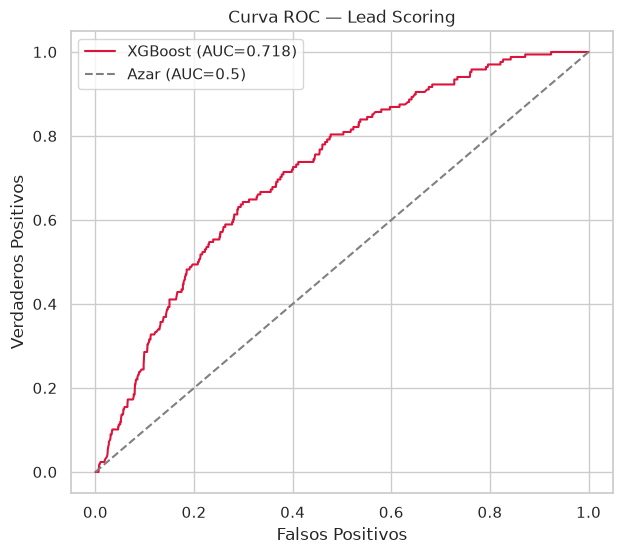

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc_test:.3f})', color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC — Lead Scoring')
plt.legend()
plt.show()

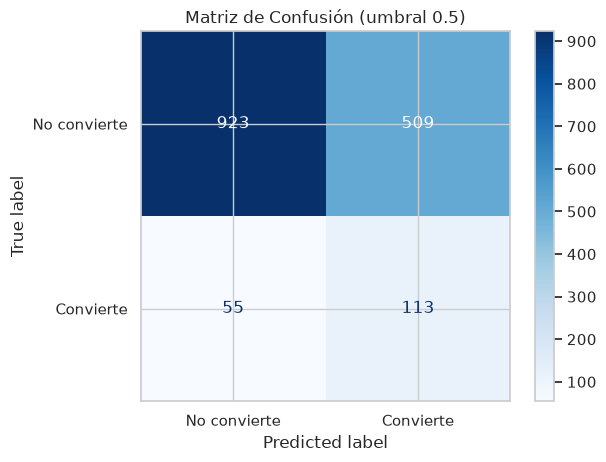

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No convierte', 'Convierte'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión (umbral 0.5)')
plt.show()

## 7. Interpretabilidad (SHAP)

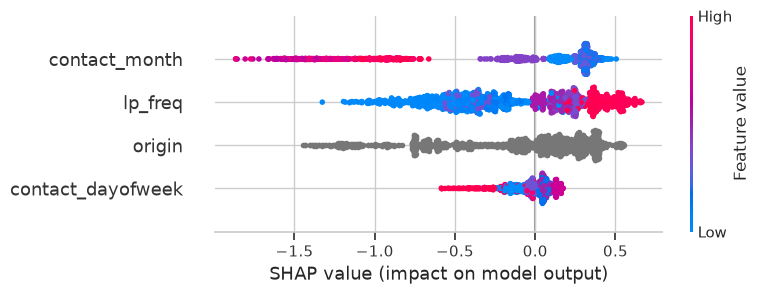

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

## 8. Guardamos el modelo

In [11]:
model_path = os.path.join(project_root, 'models', 'xgb_lead_scoring.pkl')
joblib.dump(model, model_path)
print(f"Modelo guardado en {model_path}")

Modelo guardado en ../models/xgb_lead_scoring.pkl


## 9. Resultados y limitaciones

**AUC-ROC: 0.718 en test** (contra 0.5 de un modelo al azar), con un modelo bastante más simple de lo que arrancamos probando (`max_depth=2`, alta regularización) — hiperparámetros elegidos con `GridSearchCV` y 5-fold `StratifiedKFold` **sobre train únicamente** (AUC de CV: 0.715), sin que el test participe de la selección. Que el AUC de CV y el de test queden tan cerca (0.715 vs. 0.718) es una buena señal: el modelo generaliza de forma consistente, no está ajustado al split particular de test.

Por SHAP, el orden de importancia es `contact_month` > `lp_freq` > `origin` > `contact_dayofweek`: el mes de contacto (estacionalidad) pesa más que el canal de origen. Dentro de `origin`, `paid_search` empuja hacia conversión, mientras que `email` y `other` empujan fuerte en contra — sugiere que la inversión en búsqueda paga mejor que las campañas de email para este funnel, aunque con clases tan desbalanceadas (10.5% positivos) conviene no sobre-interpretar diferencias chicas.

**Limitaciones a tener en cuenta:**
- El target es "convirtió a seller", no "convirtió en un seller que factura mucho" — como vimos al principio, el 55% de los que cierran nunca venden nada. Este modelo prioriza leads por probabilidad de conversión, no por valor esperado.
- Precision de la clase positiva es baja (0.18): de cada 100 leads que el modelo marca como "conviene perseguir", ~18 realmente convierten. Sigue siendo ~1.7x mejor que el 10.5% base, pero está lejos de ser un modelo preciso — es esperable con solo 4 features simples y ningún dato de comportamiento del lead.
- Sería el candidato natural para una v2: una vez que haya más señal de valor (revenue por seller creciendo con el tiempo), reentrenar con un target de "alto valor" en vez de "conversión".